## Setup

In [1]:
import polars as pl

from tdt4225_ex2.eda import get_data

pl.Config(set_tbl_cols=1000)

df = get_data(verify=True)

## Duplicated TRIP_IDs

In [2]:
dupe_counts = (
    df.group_by("TRIP_ID").agg(pl.len().alias("count")).filter(pl.col("count") > 1)
)
print(dupe_counts)

dupe_ids = dupe_counts["TRIP_ID"].implode()

all_dupes = df.filter(pl.col("TRIP_ID").is_in(dupe_ids)).sort(["TRIP_ID", "TIMESTAMP"])
print(all_dupes)

shape: (80, 2)
┌─────────────────────┬───────┐
│ TRIP_ID             ┆ count │
│ ---                 ┆ ---   │
│ i64                 ┆ u32   │
╞═════════════════════╪═══════╡
│ 1403323491620000600 ┆ 2     │
│ 1388279758620000080 ┆ 2     │
│ 1385928574620000080 ┆ 2     │
│ 1402132342620000571 ┆ 2     │
│ 1401346641620000319 ┆ 2     │
│ …                   ┆ …     │
│ 1392816672620000663 ┆ 2     │
│ 1388526838620000080 ┆ 2     │
│ 1389782974620000562 ┆ 2     │
│ 1394118360620000066 ┆ 2     │
│ 1397742650620000393 ┆ 2     │
└─────────────────────┴───────┘
shape: (161, 9)
┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ TRIP_ID  ┆ CALL_TYP ┆ ORIGIN_C ┆ ORIGIN_S ┆ TAXI_ID  ┆ TIMESTAM ┆ DAY_TYPE ┆ MISSING_ ┆ POLYLINE │
│ ---      ┆ E        ┆ ALL      ┆ TAND     ┆ ---      ┆ P        ┆ ---      ┆ DATA     ┆ ---      │
│ i64      ┆ ---      ┆ ---      ┆ ---      ┆ i64      ┆ ---      ┆ str      ┆ ---      ┆ list[lis │
│          ┆ str     

## DAY_TYPE distribution, overall and per date

In [3]:
print(df["DAY_TYPE"].value_counts(sort=True))
day_types_per_date = (
    df.group_by(pl.col("TIMESTAMP").dt.date().alias("DATE"))
    .agg(pl.col("DAY_TYPE").unique().sort().alias("DAY_TYPES"))
    .sort("DATE")
)
print(day_types_per_date.filter(pl.col("DAY_TYPES").list.len() > 1))

shape: (1, 2)
┌──────────┬─────────┐
│ DAY_TYPE ┆ count   │
│ ---      ┆ ---     │
│ str      ┆ u32     │
╞══════════╪═════════╡
│ A        ┆ 1710670 │
└──────────┴─────────┘
shape: (0, 2)
┌──────┬───────────┐
│ DATE ┆ DAY_TYPES │
│ ---  ┆ ---       │
│ date ┆ list[str] │
╞══════╪═══════════╡
└──────┴───────────┘


## MISSING_DATA distribution, overall and per trip

In [4]:
print(df["MISSING_DATA"].value_counts(sort=True))
print(
    df.group_by("MISSING_DATA").agg(
        trips=pl.len(),
        empty=(pl.col("POLYLINE").list.len() == 0).sum(),
        under_3=(pl.col("POLYLINE").list.len() < 3).sum(),
        avg_points=pl.col("POLYLINE").list.len().mean(),
    )
)

shape: (2, 2)
┌──────────────┬─────────┐
│ MISSING_DATA ┆ count   │
│ ---          ┆ ---     │
│ bool         ┆ u32     │
╞══════════════╪═════════╡
│ false        ┆ 1710660 │
│ true         ┆ 10      │
└──────────────┴─────────┘
shape: (2, 5)
┌──────────────┬─────────┬───────┬─────────┬────────────┐
│ MISSING_DATA ┆ trips   ┆ empty ┆ under_3 ┆ avg_points │
│ ---          ┆ ---     ┆ ---   ┆ ---     ┆ ---        │
│ bool         ┆ u32     ┆ u32   ┆ u32     ┆ f64        │
╞══════════════╪═════════╪═══════╪═════════╪════════════╡
│ false        ┆ 1710660 ┆ 5901  ┆ 43902   ┆ 48.758033  │
│ true         ┆ 10      ┆ 0     ┆ 2       ┆ 96.9       │
└──────────────┴─────────┴───────┴─────────┴────────────┘


## Top 20 ORIGIN_STANDs

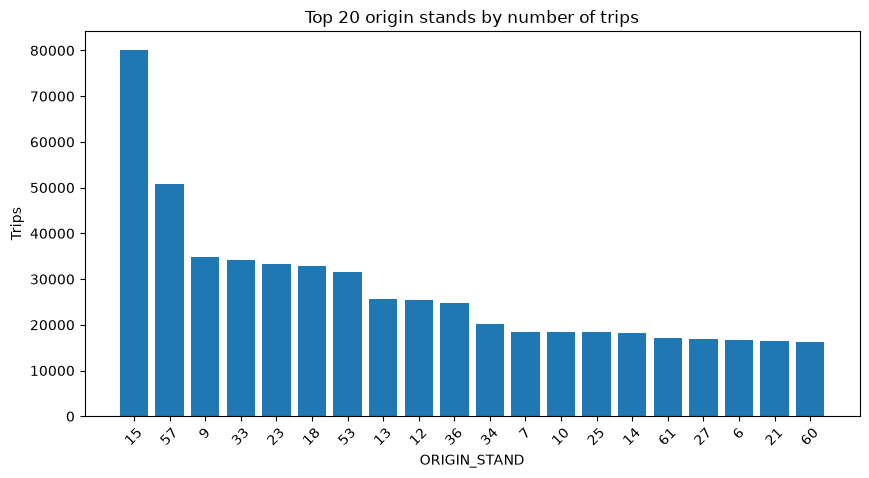

In [5]:
import matplotlib.pyplot as plt


def find_stand_locations(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df.filter(
            pl.col("CALL_TYPE").eq("B"),
            pl.col("ORIGIN_STAND").is_not_null(),
            pl.col("POLYLINE").list.len() > 0,
        )
        .select("ORIGIN_STAND", START=pl.col("POLYLINE").list.first())
        .group_by("ORIGIN_STAND")
        .agg(
            N_TRIPS=pl.len(),
            LONGITUDE=pl.col("START").list.get(0).mean(),
            LATITUDE=pl.col("START").list.get(1).mean(),
        )
        .sort("N_TRIPS", descending=True)
    )


top_stands = find_stand_locations(df).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_stands["ORIGIN_STAND"].cast(pl.String), top_stands["N_TRIPS"])
ax.set_xlabel("ORIGIN_STAND")
ax.set_ylabel("Trips")
ax.set_title("Top 20 origin stands by number of trips")
plt.xticks(rotation=45)
plt.show()

## Estimated location of every taxi stand

In [6]:
import pydeck as pdk

stands = find_stand_locations(df)


def get_rank_color(share: float) -> list[int]:
    """Colour from red (share 0, most used) to white (share 1, least used)."""
    red, white = (215, 25, 28), (255, 255, 255)
    return [round(r + (w - r) * share) for r, w in zip(red, white)]


def visualize_stands(stands: pl.DataFrame) -> None:
    stands = (
        stands.with_columns(RANK=pl.col("N_TRIPS").rank("ordinal", descending=True))
        .with_columns(SHARE=(pl.col("RANK") - 1) / max(stands.height - 1, 1))
        .sort("RANK", descending=True)
    )
    data = [
        {
            **stand,
            "RANK_LABEL": str(stand["RANK"]),
            "COLOR": get_rank_color(stand["SHARE"]),
            "TEXT_COLOR": [255, 255, 255] if stand["SHARE"] < 0.25 else [0, 0, 0],
        }
        for stand in stands.to_dicts()
    ]

    points = pdk.Layer(
        "ScatterplotLayer",
        data,
        get_position=["LONGITUDE", "LATITUDE"],
        get_fill_color="COLOR",
        get_line_color=[0, 0, 0],
        radius_units=pdk.types.String("pixels"),
        get_radius=10,
        stroked=True,
        line_width_min_pixels=1,
        pickable=True,
    )
    ranks = pdk.Layer(
        "TextLayer",
        data,
        get_position=["LONGITUDE", "LATITUDE"],
        get_text="RANK_LABEL",
        get_size=13,
        get_color="TEXT_COLOR",
        font_weight=700,
    )
    view = pdk.ViewState(latitude=41.16, longitude=-8.63, zoom=12)
    pdk.Deck(
        layers=[points, ranks],
        initial_view_state=view,
        map_provider="mapbox",
        map_style={
            "version": 8,
            "sources": {
                "satellite": {
                    "type": "raster",
                    "tiles": [
                        "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
                    ],
                    "tileSize": 256,
                    "attribution": "Esri, Maxar, Earthstar Geographics",
                }
            },
            "layers": [{"id": "satellite", "type": "raster", "source": "satellite"}],
        },
        tooltip={"text": "Stand {ORIGIN_STAND}\nRank {RANK}\n{N_TRIPS} trips"},
    ).to_html("stands.html")


with pl.Config(tbl_rows=-1):
    print(stands)

visualize_stands(stands)

shape: (63, 4)
┌──────────────┬─────────┬───────────┬───────────┐
│ ORIGIN_STAND ┆ N_TRIPS ┆ LONGITUDE ┆ LATITUDE  │
│ ---          ┆ ---     ┆ ---       ┆ ---       │
│ i64          ┆ u32     ┆ f64       ┆ f64       │
╞══════════════╪═════════╪═══════════╪═══════════╡
│ 15           ┆ 80187   ┆ -8.585705 ┆ 41.148588 │
│ 57           ┆ 50740   ┆ -8.610863 ┆ 41.14566  │
│ 9            ┆ 34767   ┆ -8.60647  ┆ 41.144631 │
│ 33           ┆ 34107   ┆ -8.600097 ┆ 41.182698 │
│ 23           ┆ 33270   ┆ -8.612591 ┆ 41.146036 │
│ 18           ┆ 32841   ┆ -8.619852 ┆ 41.148037 │
│ 53           ┆ 31499   ┆ -8.614248 ┆ 41.141323 │
│ 13           ┆ 25633   ┆ -8.628256 ┆ 41.157471 │
│ 12           ┆ 25391   ┆ -8.630543 ┆ 41.15483  │
│ 36           ┆ 24723   ┆ -8.649422 ┆ 41.154294 │
│ 34           ┆ 20251   ┆ -8.615538 ┆ 41.140738 │
│ 7            ┆ 18527   ┆ -8.639859 ┆ 41.159775 │
│ 10           ┆ 18507   ┆ -8.607127 ┆ 41.150316 │
│ 25           ┆ 18444   ┆ -8.617604 ┆ 41.146143 │
│ 14           ┆

## Visualize trip paths

In [ ]:
import random
from typing import Literal, TypedDict


class TripPath(TypedDict):
    path: list[list[float]]
    trip_id: int
    color: int


def get_color(seed: int) -> tuple[int, int, int, Literal[128]]:
    random.seed(seed)
    return tuple(random.randrange(60, 256) for _ in range(3)) + (128,)


def visualize_trip_paths(data: list[TripPath]) -> None:
    layer = pdk.Layer(
        "PathLayer",
        data,
        get_path="path",
        get_color="color",
        # get_color=[255, 128, 0, 128],
        width_min_pixels=1,
        pickable=True,
    )
    view = pdk.ViewState(latitude=41.17, longitude=-8.65, zoom=11)
    pdk.Deck(
        layers=[layer],
        initial_view_state=view,
        map_style="dark",
        tooltip={"text": "Trip {trip_id}"},
    ).to_html("routes.html")


data: list[TripPath] = [
    TripPath(
        path=row["POLYLINE"],
        trip_id=row["TRIP_ID"],
        color=get_color(row["TAXI_ID"]),
    )
    for row in df.sample(100000).iter_rows(named=True)
]
visualize_trip_paths(data)